In [ ]:
import os
import shutil
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator    # Генератор обучающих данных
from tensorflow.keras.models import Sequential      # Контейнер модели
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense  # Типы используемых слоев
from tensorflow.keras.optimizers import Adam    # Алгоритм оптимизации
import matplotlib.pyplot as plt
from zipfile import ZipFile

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Подготовка данных

In [ ]:
from sklearn.model_selection import train_test_split
import shutil
import zipfile

# Распаковываем архив
zip_path = '/content/drive/MyDrive/Лаба4/10. Butterflies - blue morpho vs crow.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/drive/MyDrive/Лаба4/')
    print("Архив распакован")

# Создаем папки train и test в Google Drive
base_path = '/content/drive/My Drive/Лаба4'
os.makedirs(f'{base_path}/train/BLUE_MORPHO', exist_ok=True)
os.makedirs(f'{base_path}/train/BLUE_SPOTTED_CROW', exist_ok=True)
os.makedirs(f'{base_path}/test/BLUE_MORPHO', exist_ok=True)
os.makedirs(f'{base_path}/test/BLUE_SPOTTED_CROW', exist_ok=True)

print("Созданы папки в Google Drive:")
print(f"- {base_path}/train/BLUE_MORPHO")
print(f"- {base_path}/train/BLUE_SPOTTED_CROW")
print(f"- {base_path}/test/BLUE_MORPHO")
print(f"- {base_path}/test/BLUE_SPOTTED_CROW")

# Разделяем файлы
dataset_path = f'{base_path}/10. Butterflies - blue morpho vs crow'

for class_name in ['BLUE MORPHO', 'BLUE SPOTTED CROW']:
    class_path = f'{dataset_path}/{class_name}'
    all_files = os.listdir(class_path)
    train_files, test_files = train_test_split(all_files, test_size=0.2, random_state=42)

    for file in train_files:
        shutil.copy2(f'{class_path}/{file}', f'{base_path}/train/{class_name.replace(" ", "_")}/{file}')

    for file in test_files:
        shutil.copy2(f'{class_path}/{file}', f'{base_path}/test/{class_name.replace(" ", "_")}/{file}')

    print(f"{class_name}: {len(train_files)} train, {len(test_files)} test")

print("Готово! Данные разделены в Google Drive")

Архив распакован
Созданы папки в Google Drive:
- /content/drive/My Drive/Лаба4/train/BLUE_MORPHO
- /content/drive/My Drive/Лаба4/train/BLUE_SPOTTED_CROW
- /content/drive/My Drive/Лаба4/test/BLUE_MORPHO
- /content/drive/My Drive/Лаба4/test/BLUE_SPOTTED_CROW
BLUE MORPHO: 85 train, 22 test
BLUE SPOTTED CROW: 98 train, 25 test
Готово! Данные разделены в Google Drive


# Построение модели

In [ ]:
model = Sequential()
model.add(Input(shape=(150, 150, 3)))  # указываем размер входных изображений - 150 х 150, 3 цветовых канала
model.add(Conv2D(32, (3, 3), activation='relu', padding='SAME'))
model.add(MaxPooling2D())
model.add(Conv2D(64, (3, 3), activation='relu', padding='SAME'))
model.add(MaxPooling2D())
model.add(Conv2D(128, (3, 3), activation='relu', padding='SAME'))
model.add(MaxPooling2D())
model.add(Conv2D(128, (3, 3), activation='relu', padding='SAME'))
model.add(MaxPooling2D())
model.add(Conv2D(128, (3, 3), activation='relu', padding='SAME'))
model.add(MaxPooling2D())
model.add(Conv2D(128, (3, 3), activation='relu', padding='SAME'))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 9, 9, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,201 (2.55 MB)

 Trainable params: 667,201 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

# Подготовка данных для обучения модели

In [ ]:
# Сохраняем пути к папкам в переменные TRAIN_DIR, TEST_DIR
TRAIN_DIR = f'{base_path}/train'
TEST_DIR = f'{base_path}/test'

In [ ]:
train_datagen = ImageDataGenerator(rescale=1/255)
test_datagen = ImageDataGenerator(rescale=1/255)

In [ ]:
train_generator = train_datagen.flow_from_directory(TRAIN_DIR,
                                                    target_size=(150, 150),
                                                    batch_size=128,
                                                    shuffle=True,
                                                    class_mode='binary')

test_generator = test_datagen.flow_from_directory(TEST_DIR,
                                                    target_size=(150, 150),
                                                    batch_size=128,
                                                    shuffle=False,
                                                    class_mode='binary')

Found 183 images belonging to 2 classes.
Found 47 images belonging to 2 classes.


In [ ]:
print("Соответствие классов:")
print(train_generator.class_indices)

Соответствие классов:
{'BLUE_MORPHO': 0, 'BLUE_SPOTTED_CROW': 1}


# Обучение модели

In [ ]:
model.compile(loss='binary_crossentropy',
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])

In [ ]:
history = model.fit(
        train_generator,
        validation_data=test_generator,
        steps_per_epoch=30,
        epochs=40
      )

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
 2/30 ━━━━━━━━━━━━━━━━━━━━ 3:07 7s/step - accuracy: 0.5224 - loss: 0.6915 

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


30/30 ━━━━━━━━━━━━━━━━━━━━ 19s 328ms/step - accuracy: 0.5652 - loss: 0.6903 - val_accuracy: 0.6383 - val_loss: 0.6619
Epoch 2/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 293ms/step - accuracy: 0.5242 - loss: 0.7497 - val_accuracy: 0.6809 - val_loss: 0.6276
Epoch 3/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step - accuracy: 0.6198 - loss: 0.6577 - val_accuracy: 0.7447 - val_loss: 0.6349
Epoch 4/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 243ms/step - accuracy: 0.8072 - loss: 0.6325 - val_accuracy: 0.7234 - val_loss: 0.6392
Epoch 5/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 303ms/step - accuracy: 0.8078 - loss: 0.6243 - val_accuracy: 0.7660 - val_loss: 0.6033
Epoch 6/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 165ms/step - accuracy: 0.8083 - loss: 0.5799 - val_accuracy: 0.8085 - val_loss: 0.5047
Epoch 7/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 238ms/step - accuracy: 0.8091 - loss: 0.4571 - val_accuracy: 0.7660 - val_loss: 0.4500
Epoch 8/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 240ms/step - accuracy: 0.7985 - loss: 0.4739 - val_accuracy: 0.553

# Графики функции потерь и точности на обучающей и тестовой выборке

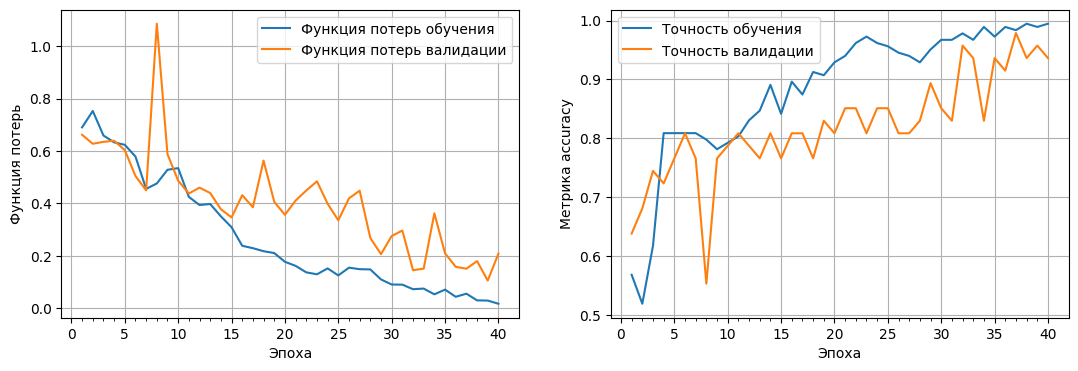

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4))
axs[0].plot(np.arange(1, len(history.history['loss']) + 1), history.history['loss'][:], label='Функция потерь обучения')
axs[0].plot(np.arange(1, len(history.history['loss']) + 1), history.history['val_loss'][:], label='Функция потерь валидации')
axs[0].grid()
axs[0].set_xticks(np.arange(0, len(history.history['loss']) + 1, 5))
axs[0].set_xticks(np.arange(0, len(history.history['loss']) + 1, 1), minor=True)
axs[0].legend(prop={'size': 10})
axs[0].set_xlabel('Эпоха')
axs[0].set_ylabel('Функция потерь')

axs[1].plot(np.arange(1, len(history.history['accuracy']) + 1), history.history['accuracy'][:], label='Точность обучения')
axs[1].plot(np.arange(1, len(history.history['accuracy']) + 1), history.history['val_accuracy'][:], label='Точность валидации')
axs[1].grid()
axs[1].set_xticks(np.arange(0, len(history.history['accuracy']) + 1, 5))
axs[1].set_xticks(np.arange(0, len(history.history['accuracy']) + 1, 1), minor=True)
axs[1].legend(prop={'size': 10})
axs[1].set_xlabel('Эпоха')
axs[1].set_ylabel('Метрика accuracy')
plt.show()

# Проверка модели

In [ ]:
image = Image.open('/content/drive/My Drive/Лаба4/blue morpho.jpg')
image = image.resize((150, 150))
image = np.array(image).reshape((1, 150, 150, 3))
model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


array([[0.]], dtype=float32)

In [ ]:
image = Image.open('/content/drive/My Drive/Лаба4/crow.jpg')
image = image.resize((150, 150))
image = np.array(image).reshape((1, 150, 150, 3))
model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


array([[1.]], dtype=float32)